# Gauss-Newton Algorithm for Nonlinear Curve Fitting of Cd vs Re Data
## Bradley Canty, 2023/11/08

References:\
https://en.wikipedia.org/wiki/Gauss%E2%80%93Newton_algorithm \
https://sakurachaojun.github.io/PSYO3505/others/latex.html

In [70]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from scipy import linalg as la

Our baseball trajectory simulation requires the correspondance of drag coefficient with Reynolds number. The wind tunnel observations are discrete points: we want to fit a curve to this data to have a continuous mapping between Reynolds number and drag coefficient.

Reynolds number data, the independent variable, is given by:

In [71]:
Re = np.array([8.367321716000000015e+04,
    8.587514393000000564e+04,
    9.027899745999999868e+04,
    9.468285099999999511e+04,
    9.688477775999999722e+04,
    9.798574115000000165e+04,
    1.034905580999999947e+05,
    1.045915215000000026e+05,
    1.056924848000000056e+05,
    1.078944116000000067e+05,
    1.100963383999999933e+05,
    1.122982651000000042e+05,
    1.167021187000000064e+05,
    1.211059722000000038e+05,
    1.244088623999999982e+05,
    1.266107890999999945e+05,
    1.343175327999999863e+05,
    1.365194596000000020e+05,
    1.376204230000000098e+05,
    1.387213863000000129e+05,
    1.409233130999999994e+05,
    1.431252398999999859e+05,
    1.431252398999999859e+05,
    1.475290934000000125e+05,
    1.497310201999999990e+05,
    1.519329469000000099e+05,
    1.530339102999999886e+05,
    1.563368005000000121e+05,
    1.574377638999999908e+05,
    1.618416173999999883e+05,
    1.651445076000000117e+05,
    1.706493244999999879e+05,
    1.739522146000000066e+05,
    1.805579948999999906e+05,
    1.849618484999999928e+05,
    1.882647386000000115e+05,
    1.915676288000000059e+05,
    1.937695554999999877e+05,
    2.003753358000000007e+05,
    2.025772625999999873e+05,
    2.113849696999999869e+05,
    2.135868963999999978e+05,
    2.223946034999999974e+05,
    2.312023105999999971e+05,
    2.323032740000000049e+05,
    2.389090542999999889e+05,
    2.422119444000000076e+05,
    2.444138711999999941e+05,
    2.488177246999999916e+05,
    2.532215781999999890e+05,
    2.576254317999999912e+05,
    2.642312121000000043e+05,
    2.708369923999999883e+05,
    2.730389192000000039e+05,
    2.774427726999999722e+05,
    2.818466261999999988e+05,
    2.928562601000000141e+05])

Baseball drag coefficient data, the dependent variable, is given by:

In [72]:
Cd = np.array([4.899999999999999911e-01,
    4.500000000000000111e-01,
    4.299999999999999933e-01,
    4.699999999999999734e-01,
    4.650000000000000244e-01,
    4.450000000000000067e-01,
    4.249999999999999889e-01,
    4.349999999999999978e-01,
    4.199999999999999845e-01,
    4.000000000000000222e-01,
    4.400000000000000022e-01,
    4.199999999999999845e-01,
    3.900000000000000133e-01,
    4.149999999999999800e-01,
    4.050000000000000266e-01,
    3.950000000000000178e-01,
    4.000000000000000222e-01,
    3.950000000000000178e-01,
    3.900000000000000133e-01,
    3.649999999999999911e-01,
    3.499999999999999778e-01,
    3.750000000000000000e-01,
    3.900000000000000133e-01,
    3.900000000000000133e-01,
    3.750000000000000000e-01,
    3.800000000000000044e-01,
    3.599999999999999867e-01,
    3.649999999999999911e-01,
    3.800000000000000044e-01,
    3.599999999999999867e-01,
    3.350000000000000200e-01,
    3.449999999999999734e-01,
    3.150000000000000022e-01,
    3.300000000000000155e-01,
    2.800000000000000266e-01,
    3.300000000000000155e-01,
    2.700000000000000178e-01,
    2.899999999999999800e-01,
    2.750000000000000222e-01,
    2.899999999999999800e-01,
    2.750000000000000222e-01,
    2.899999999999999800e-01,
    2.800000000000000266e-01,
    2.949999999999999845e-01,
    2.800000000000000266e-01,
    2.949999999999999845e-01,
    2.800000000000000266e-01,
    2.979999999999999871e-01,
    2.800000000000000266e-01,
    2.750000000000000222e-01,
    2.650000000000000133e-01,
    2.750000000000000222e-01,
    3.099999999999999978e-01,
    3.049999999999999933e-01,
    2.999999999999999889e-01,
    2.600000000000000089e-01,
    2.800000000000000266e-01])

Lets visualize the data:

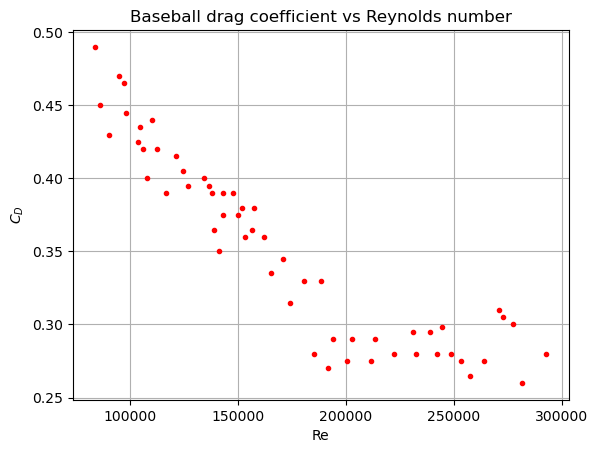

In [73]:
plt.plot(Re,Cd,'r.')
plt.xlabel('Re')
plt.ylabel('$C_D$')
plt.title('Baseball drag coefficient vs Reynolds number')
plt.grid(True)

The data resembles an exponentially decaying curve. To fit the data to such a curve, we can apply nonlinear least-squares regression (a.k.a Gauss-Newton curve fit).

A good candidate model to fit to the data is

$C_D = f(Re) = \beta_1*e^{\beta_2*Re} + \beta_3$

Here, $C_D$ is the drag coefficient on the baseball, $Re$ is the Reynolds number, and $\beta_1$, $\beta_2$, and $\beta_3$ are unknown parameters to be found.
The parameters are estimated by minimizing the sum of the squared differences (residuals) between the observed data and the predicted values.

First, define a residual function: the residual is defined as\
$r = C_d - f(Re, \beta_1,\beta_2,\beta_3)$

In [74]:
def residual(beta):
    return Cd - (beta[0] * np.exp(beta[1] * Re) + beta[2])

Next, define its Jacobian matrix

In [75]:
def jacobian(beta):
    return np.array([
        -np.exp(beta[1] * Re),
        -beta[0] * Re * np.exp(beta[1] * Re),
        -np.ones(Re.shape[0])
    ]).T

In [76]:
#jacobian(np.array([1,0]))

We need to make an inital guess for parameters $\beta_1$, $\beta_2$, and $\beta_3$.\
Define a function to compute the residual norm of the guesses:

In [77]:
def residual_norm():
    return la.norm(residual(beta),2)

Define a plotting function to check the quality of initial guesses:

In [78]:
def plot_guess(i):
    plt.figure()
    
    #plot the data
    plt.plot(Re,Cd,'ro',clip_on=False)
    
    #plot the guessed curve
    RE = np.linspace(Re.min(),Re.max(),100)
    CD = beta[0] * np.exp(beta[1] * RE) + beta[2]
    plt.plot(RE,CD,'b-')
    plt.grid(True)
    plt.xlabel('Re')
    plt.ylabel('$C_D$')
    plt.title('Baseball Drag Coefficient vs Reynolds Number, iter = {}'.format(i))

Make an initial guess for the parameters and visually check it against the data:

Residual norm: 0.22888020936798475


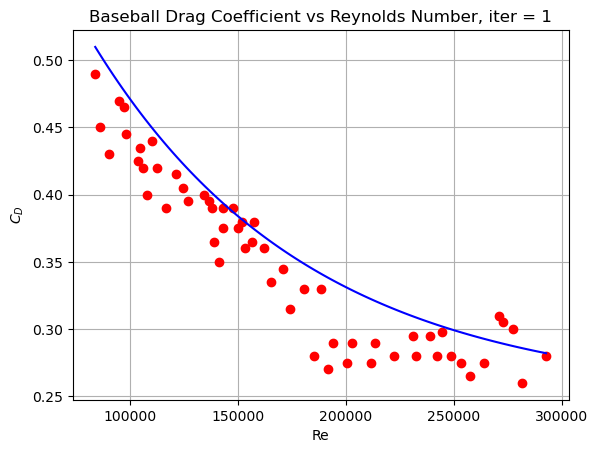

In [79]:
beta = [0.6,-1e-5,0.25]
print('Residual norm: {}'.format(residual_norm()))
plot_guess(1)

Using this initial guess, apply the Gauss-Newton algorithm. Use numpy.linalg.lstsq() to solve the least-square problem, note that the function returns a tuple, the first entry of which is the desired solution.

Iter 2 residual norm: 0.14516282515651496
Iter 3 residual norm: 0.14495607438186592
Iter 4 residual norm: 0.1449559957993175


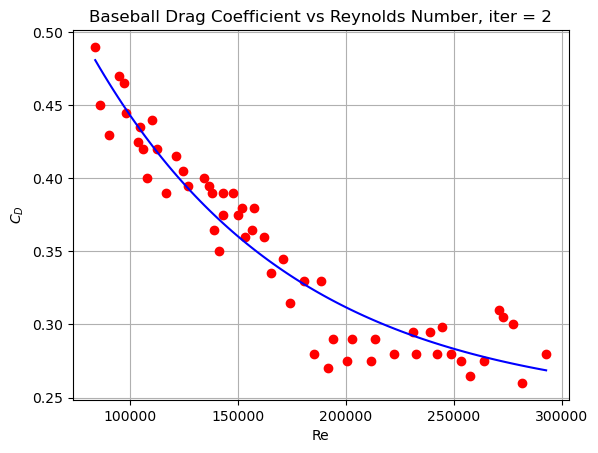

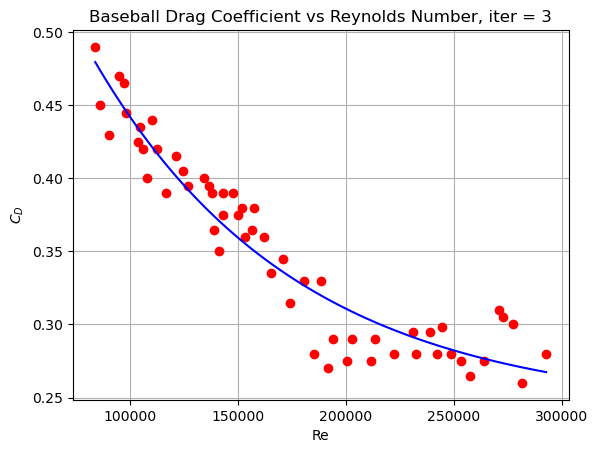

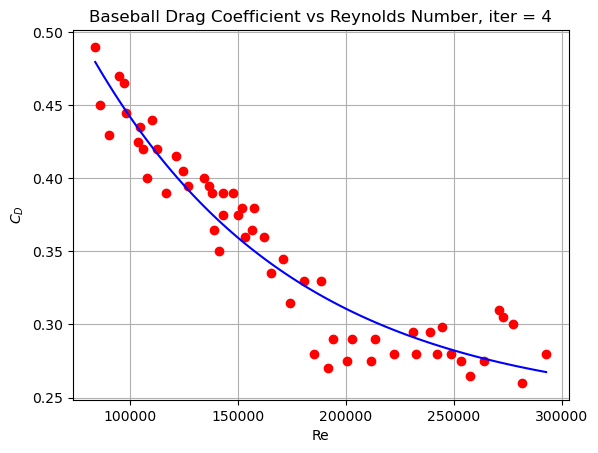

In [80]:
for i in range(2,5):
    beta = beta + la.lstsq(jacobian(beta),-residual(beta))[0]
    print('Iter {} residual norm: {}'.format(i,residual_norm()))
    plot_guess(i)

The curve fit parameters after 4 iterations are given by the beta vector:

$\beta_1$ is given by

In [81]:
beta[0]

np.float64(0.5793760675669767)

$\beta_2$ is given by

In [82]:
beta[1]

np.float64(-1.0633061981411887e-05)

$\beta_3$ is given by

In [83]:
beta[2]

np.float64(0.24169961470570514)

Thus, the final exponential decay curve fit for the baseball drag coefficient is\
$C_D = 0.5793 * e^{-1.0630e-5*Re} + 0.2417$

This curve does not appear to closely fit the data in the region of Re = 200000. A better fit can be obtained using a piecewise linear fit.
To do this, we fit two linear least-squares fit lines to the data where one line corresponds to data having Re < 200000 and the other corresponds to data having Re > 200000.

In [84]:
Re1 = []
Cd1 = []

Re2 = []
Cd2 = []

for i in range(0,Re.shape[0]):
    if Re[i] < 200000:
        Re1.append(Re[i])
        Cd1.append(Cd[i])
    else:
        Re2.append(Re[i])
        Cd2.append(Cd[i])

Apply least-squares linear regression on each list pair to find the slope and displacement of the line. We start with the standard system of equations:\
$A*x = b$\
The slope and the displacement, the x vector, is unknown to us, so rearrange to solve for x:\
$x = (A^T*A)^{-1}*A^T*b = [a;Cd_0]$\
where\
A = matrix of known values = $[Re_1,1;Re_2,1;...;Re_N,1]$\
b = solution vector = $[Cd_1;Cd_2;...;Cd_N]$\
a = slope = $\Delta Cd / \Delta Re$\
$Cd_0$ = initial displacement

The first curve fit, for Re < 200000:

In [85]:
A1 = np.matrix([Re1,np.ones(len(Re1))]).T
b1 = np.matrix(Cd1).T
x1 = np.dot(np.dot(np.linalg.inv(np.dot(A1.T,A1)),A1.T),b1) #1st entry is slope, 2nd entry is displacement

The second curve fit, for Re >= 200000:

In [86]:
A2 = np.matrix([Re2,np.ones(len(Re2))]).T
b2 = np.matrix(Cd2).T
x2 = np.dot(np.dot(np.linalg.inv(np.dot(A2.T,A2)),A2.T),b2) #1st entry is slope, 2nd entry is displacement

Solve for point where lines intersect\
that is, find Re where\
$x1[0]*Re + x1[1] = x2[0]*Re + x2[1]$

In [87]:
ReEqual = (x2[1]-x1[1]) / (x1[0] - x2[0])
ReEqual = 204000

Plot the piecewise continuous line fit over the data:

C:\Users\bradl\AppData\Local\Temp\ipykernel_8784\1791208659.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  [float(Re1[0]*x1[0] + x1[1]),float(ReEqual*x1[0] + x1[1])],'c')
C:\Users\bradl\AppData\Local\Temp\ipykernel_8784\1791208659.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  [float(ReEqual*x2[0] + x2[1]),float(Re2[-1]*x2[0] + x2[1])],'m')


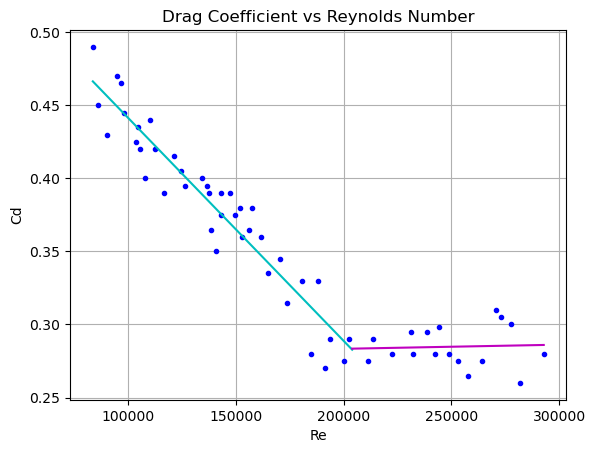

In [88]:
#Create scatter plot of Cd vs Re
plt.figure()
plt.plot(Re,Cd,'b.')
plt.title('Drag Coefficient vs Reynolds Number')
plt.xlabel('Re')
plt.ylabel('Cd')
plt.grid(True)

#Plot the 1st curve fit
plt.plot([Re1[0],ReEqual],
         [float(Re1[0]*x1[0] + x1[1]),float(ReEqual*x1[0] + x1[1])],'c')

#Plot the 2nd curve fit
plt.plot([ReEqual,Re2[-1]],
         [float(ReEqual*x2[0] + x2[1]),float(Re2[-1]*x2[0] + x2[1])],'m')

The slope of the line for Re < 200000 is

In [89]:
x1[0]

matrix([[-1.52664361e-06]])

The displacement of Cd when Re = 0 for Re < 200000 is

In [90]:
x1[1]

matrix([[0.59416069]])

The slope of the line for Re >= 200000 is

In [91]:
x2[0]

matrix([[2.83876989e-08]])

The displacement of Cd when Re = 0 for Re >= 200000 is

In [92]:
x2[1]

matrix([[0.2776702]])

Finally, 
The equation for Cd when Re < 200000 is:\
$C_d = Re*-1.52664361e-06 + 0.59416069$

The equation for Cd when Re >= 20000 is:\
$C_d = Re*2.83876989e-08 + 0.2776702$
